## **1. Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

## **2. Prepare data**

In [2]:
data = {
    'ID': [1, 2, 3, 4, 5, 6],
    'Màu tóc': ['Đen', 'Đen', 'Râm', 'Nâu', 'Nâu', 'Râm'],
    'Chiều cao': ['Trung bình', 'Cao', 'Thấp', 'Thấp', 'Trung bình', 'Trung bình'],
    'Cân nặng': ['Nhẹ', 'Trung bình', 'Trung bình', 'Trung bình', 'Nặng', 'Nặng'],
    'Dùng kem': ['Không', 'Có', 'Có', 'Không', 'Không', 'Có'],
    'Kết quả': ['Cháy nắng', 'Không', 'Không', 'Cháy nắng', 'Cháy nắng', 'Không']
}
df_train = pd.DataFrame(data).set_index('ID')
print("Training data:")
print(df_train)

Training data:
   Màu tóc   Chiều cao    Cân nặng Dùng kem    Kết quả
ID                                                    
1      Đen  Trung bình         Nhẹ    Không  Cháy nắng
2      Đen         Cao  Trung bình       Có      Không
3      Râm        Thấp  Trung bình       Có      Không
4      Nâu        Thấp  Trung bình    Không  Cháy nắng
5      Nâu  Trung bình        Nặng    Không  Cháy nắng
6      Râm  Trung bình        Nặng       Có      Không


In [3]:
test_sample = {
    'Màu tóc': 'Nâu',
    'Chiều cao': 'Trung bình', 
    'Cân nặng': 'Nhẹ',
    'Dùng kem': 'Có'
}
print("Test sample:")
for key, value in test_sample.items():
    print(f"{key}: {value}")

Test sample:
Màu tóc: Nâu
Chiều cao: Trung bình
Cân nặng: Nhẹ
Dùng kem: Có


### **Create Bootstrap samples**

In [4]:
d1_ids = [1, 5, 2, 6, 5, 3]
d2_ids = [4, 1, 6, 2, 4, 2]
d3_ids = [3, 4, 1, 4, 5, 3]

df1 = df_train.loc[d1_ids]
df2 = df_train.loc[d2_ids]
df3 = df_train.loc[d3_ids]

print("Bootstrap Sample D1:")
print(df1)
print("\nBootstrap Sample D2:")
print(df2)
print("\nBootstrap Sample D3:")
print(df3)

Bootstrap Sample D1:
   Màu tóc   Chiều cao    Cân nặng Dùng kem    Kết quả
ID                                                    
1      Đen  Trung bình         Nhẹ    Không  Cháy nắng
5      Nâu  Trung bình        Nặng    Không  Cháy nắng
2      Đen         Cao  Trung bình       Có      Không
6      Râm  Trung bình        Nặng       Có      Không
5      Nâu  Trung bình        Nặng    Không  Cháy nắng
3      Râm        Thấp  Trung bình       Có      Không

Bootstrap Sample D2:
   Màu tóc   Chiều cao    Cân nặng Dùng kem    Kết quả
ID                                                    
4      Nâu        Thấp  Trung bình    Không  Cháy nắng
1      Đen  Trung bình         Nhẹ    Không  Cháy nắng
6      Râm  Trung bình        Nặng       Có      Không
2      Đen         Cao  Trung bình       Có      Không
4      Nâu        Thấp  Trung bình    Không  Cháy nắng
2      Đen         Cao  Trung bình       Có      Không

Bootstrap Sample D3:
   Màu tóc   Chiều cao    Cân nặng Dùng kem    Kết quả


## **3. Helper functions for Decision Tree**

#### Define Gini impurity and Gini gain functions

In [12]:
df1["Kết quả"].value_counts(normalize=True)**2

Kết quả
Cháy nắng    0.25
Không        0.25
Name: proportion, dtype: float64

In [15]:
def gini_impurity(series: pd.Series) -> float:
    ### YOU CODE HERE
    probas = series.value_counts(normalize=True).values
    return 1 - np.sum(probas**2)
    ### END OF YOUR CODE

def gini_gain(
    data: pd.DataFrame, 
    split_feature: str, 
    target_feature: str = "Kết quả"
) -> float:
    parent_gini = gini_impurity(data[target_feature])
    
    weighted_child_gini = 0.0
    for value, subset in data.groupby(split_feature):
        weight = len(subset) / len(data)
        child_gini = gini_impurity(subset[target_feature])
        weighted_child_gini += weight * child_gini
    
    gain = parent_gini - weighted_child_gini
    return float(gain)

print("Testing Gini functions:")
print(f"Gini impurity of original data: {gini_impurity(df_train['Kết quả']):.3f}")
print(f"Gini gain for 'Màu tóc': {gini_gain(df_train, 'Màu tóc'):.3f}")

Testing Gini functions:
Gini impurity of original data: 0.500
Gini gain for 'Màu tóc': 0.333


#### Build simple Decision Tree class

In [16]:
class SimpleDecisionTree:
    def __init__(self, max_depth=3, feature_selection_rules=None):
        self.max_depth = max_depth
        self.tree = None
        # Rules for which features to use at each node (simulating random selection)
        self.feature_selection_rules = feature_selection_rules or {}
        
    def find_best_split(self, data, features):
        best_feature = None
        best_gain = -1
        
        for feature in features:
            gain = gini_gain(data, feature)
            if gain > best_gain:
                best_gain = gain
                best_feature = feature
        
        return best_feature, best_gain
    
    def is_pure(self, data):
        return len(data['Kết quả'].unique()) == 1
    
    def get_majority_class(self, data):
        return data['Kết quả'].mode()[0]
    
    def build_tree(self, data, all_features, depth=0, path="root"):
        if self.is_pure(data) or depth >= self.max_depth or len(data) <= 1:
            return self.get_majority_class(data)

        # Get random subset of features for this node
        if path in self.feature_selection_rules:
            features = self.feature_selection_rules[path]
            print(f"Node '{path}': Random features = {features}")
        else:
            # Default: use all features (shouldn't happen in our example)
            features = all_features
            print(f"Node '{path}': Using all features {features}")

        best_feature, best_gain = self.find_best_split(data, features)
        
        if best_gain == 0:
            return self.get_majority_class(data)
        
        tree = {
            'feature': best_feature,
            'gain': best_gain,
            'children': {}
        }
        
        for value in data[best_feature].unique():
            subset = data[data[best_feature] == value]
            child_path = f"{path}.{best_feature}={value}"
            tree['children'][value] = self.build_tree(subset, all_features, depth + 1, child_path)
        
        return tree
    
    def fit(self, data, all_features):
        print("Building tree with random feature selection at each node...")
        self.tree = self.build_tree(data, all_features)
        return self
    
    def predict_single(self, sample):
        node = self.tree
        
        while isinstance(node, dict):
            feature = node['feature']
            value = sample[feature]
            
            if value in node['children']:
                node = node['children'][value]
            else:
                return "Không"
        
        return node
    
    def print_tree(self, node=None, prefix=""):
        if node is None:
            node = self.tree

        if isinstance(node, dict):
            feature = node['feature']
            print(f"{prefix}Split: '{feature}' (Gain: {node['gain']:.3f})")

            children = list(node['children'].items())
            for i, (value, child) in enumerate(children):
                last = (i == len(children) - 1)
                branch = "└──" if last else "├──"
                print(f"{prefix}{branch} If {feature} = '{value}':")
                new_prefix = prefix + ("    " if last else "│   ")
                self.print_tree(child, new_prefix)
        else:
            print(f"{prefix}Predict: {node}")
    
    def show_graphviz(self):
        from graphviz import Digraph

        g = Digraph("DecisionTree", format="png")
        g.attr(rankdir="TB", nodesep="0.25", ranksep="0.35", fontsize="10")
        g.attr("node", shape="box", style="rounded", fontname="Helvetica", fontsize="10")
        g.attr("edge", fontname="Helvetica", fontsize="9")

        counter = {"i": 0}

        def add(node, parent_id=None, edge_label=None):
            nid = f"n{counter['i']}"
            counter["i"] += 1

            if isinstance(node, dict):
                label = f"{node['feature']}\\nGain: {node['gain']:.3f}"
                g.node(nid, label=label, shape="box")
                if parent_id is not None:
                    g.edge(parent_id, nid, label=str(edge_label))
                for value, child in node['children'].items():
                    add(child, nid, value)
            else:
                g.node(nid, label=f"Predict: {node}", shape="ellipse")
                if parent_id is not None:
                    g.edge(parent_id, nid, label=str(edge_label))

            return nid

        add(self.tree)
        return g 

print("Decision Tree class created successfully!")

Decision Tree class created successfully!


## **4. Build individual Decision Trees**

#### Train Tree 1 on bootstrap sample D1

=== TREE 1 (trained on D1) ===
Random Forest: Feature selection at each node split
Building tree with random feature selection at each node...
Node 'root': Random features = ['Màu tóc', 'Dùng kem']

Tree structure:
Split: 'Dùng kem' (Gain: 0.500)
├── If Dùng kem = 'Không':
│   Predict: Cháy nắng
└── If Dùng kem = 'Có':
    Predict: Không

Prediction for test sample: Không


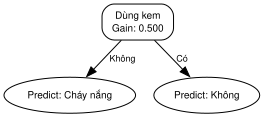

In [18]:
all_features = ['Màu tóc', 'Chiều cao', 'Cân nặng', 'Dùng kem']

# Tree 1: Feature selection rules for each node
# Root: randomly select {Màu tóc, Dùng kem}
tree1_rules = {
    "root": ['Màu tóc', 'Dùng kem']
}

print("=== TREE 1 (trained on D1) ===")
print("Random Forest: Feature selection at each node split")
### YOU CODE HERE
tree1 = SimpleDecisionTree(feature_selection_rules=tree1_rules).fit(df1, all_features)
### END OF YOUR CODE

print("\nTree structure:")
tree1.print_tree()

prediction1 = tree1.predict_single(test_sample)
print(f"\nPrediction for test sample: {prediction1}")
tree1.show_graphviz()

#### Train Tree 2 on bootstrap sample D2

=== TREE 2 (trained on D2) ===
Random Forest: Feature selection at each node split
Building tree with random feature selection at each node...
Node 'root': Random features = ['Chiều cao', 'Cân nặng']
Node 'root.Chiều cao=Trung bình': Random features = ['Màu tóc', 'Dùng kem']

Tree structure:
Split: 'Chiều cao' (Gain: 0.333)
├── If Chiều cao = 'Thấp':
│   Predict: Cháy nắng
├── If Chiều cao = 'Trung bình':
│   Split: 'Màu tóc' (Gain: 0.500)
│   ├── If Màu tóc = 'Đen':
│   │   Predict: Cháy nắng
│   └── If Màu tóc = 'Râm':
│       Predict: Không
└── If Chiều cao = 'Cao':
    Predict: Không

Prediction for test sample: Không


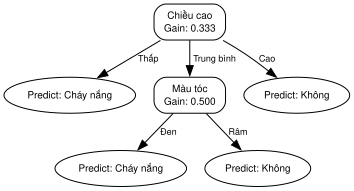

In [19]:
# Tree 2: Feature selection rules for each node
# Root: randomly select {Chiều cao, Cân nặng}
# Branch Trung bình: randomly select {Màu tóc, Dùng kem}
tree2_rules = {
    "root": ['Chiều cao', 'Cân nặng'],
    "root.Chiều cao=Trung bình": ['Màu tóc', 'Dùng kem']
}

print("=== TREE 2 (trained on D2) ===")
print("Random Forest: Feature selection at each node split")
### YOU CODE HERE
tree2 = SimpleDecisionTree(feature_selection_rules=tree2_rules).fit(df2, all_features)
### END OF YOUR CODE

print("\nTree structure:")
tree2.print_tree()

prediction2 = tree2.predict_single(test_sample)
print(f"\nPrediction for test sample: {prediction2}")
tree2.show_graphviz()

#### Train Tree 3 on bootstrap sample D3

=== TREE 3 (trained on D3) ===
Random Forest: Feature selection at each node split
Building tree with random feature selection at each node...
Node 'root': Random features = ['Cân nặng', 'Dùng kem']

Tree structure:
Split: 'Dùng kem' (Gain: 0.444)
├── If Dùng kem = 'Có':
│   Predict: Không
└── If Dùng kem = 'Không':
    Predict: Cháy nắng

Prediction for test sample: Không


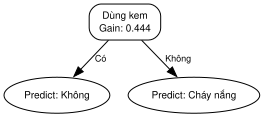

In [20]:
# Tree 3: Feature selection rules for each node
# Root: randomly select {Cân nặng, Dùng kem}
tree3_rules = {
    "root": ['Cân nặng', 'Dùng kem']
}

print("=== TREE 3 (trained on D3) ===")
print("Random Forest: Feature selection at each node split")
### YOU CODE HERE
tree3 = SimpleDecisionTree(feature_selection_rules=tree3_rules).fit(df3, all_features)
### END OF YOUR CODE

print("\nTree structure:")
tree3.print_tree()

prediction3 = tree3.predict_single(test_sample)
print(f"\nPrediction for test sample: {prediction3}")
tree3.show_graphviz()

## **5. Implement Random Forest**

#### Combine predictions using majority voting

In [22]:
class SimpleRandomForest:
    def __init__(self, n_trees=3):
        self.n_trees = n_trees
        self.trees = []
        
    def fit(self, bootstrap_samples, feature_rules_list, all_features):
        self.trees = []
        
        for i, (sample, rules) in enumerate(zip(bootstrap_samples, feature_rules_list)):
            print(f"\nTraining tree {i+1}...")
            ### YOU CODE HERE
            tree = SimpleDecisionTree(feature_selection_rules=rules).fit(sample, all_features)
            ### END OF YOUR CODE
            self.trees.append(tree)
        
        print(f"\nRandom Forest trained with {len(self.trees)} trees")
        print("Each node uses random subset of features for splitting")
    
    def predict(self, sample):
        predictions = []
        
        for i, tree in enumerate(self.trees):
            pred = tree.predict_single(sample)
            predictions.append(pred)
            print(f"Tree {i+1} prediction: {pred}")
        
        # Count votes
        vote_counts = Counter(predictions)
        final_prediction = vote_counts.most_common(1)[0][0]
        
        print(f"All predictions: {predictions}")
        print(f"Vote counts: {dict(vote_counts)}")
        print(f"Final prediction: {final_prediction}")
        
        return final_prediction

print("=== RANDOM FOREST ===")

rf = SimpleRandomForest(n_trees=3)
bootstrap_samples = [df1, df2, df3]
feature_rules_list = [tree1_rules, tree2_rules, tree3_rules]
rf.fit(bootstrap_samples, feature_rules_list, all_features)

=== RANDOM FOREST ===

Training tree 1...
Building tree with random feature selection at each node...
Node 'root': Random features = ['Màu tóc', 'Dùng kem']

Training tree 2...
Building tree with random feature selection at each node...
Node 'root': Random features = ['Chiều cao', 'Cân nặng']
Node 'root.Chiều cao=Trung bình': Random features = ['Màu tóc', 'Dùng kem']

Training tree 3...
Building tree with random feature selection at each node...
Node 'root': Random features = ['Cân nặng', 'Dùng kem']

Random Forest trained with 3 trees
Each node uses random subset of features for splitting


#### Make prediction on test sample

In [24]:
print("\n=== RANDOM FOREST PREDICTION ===")
print("Test sample:", test_sample)
print("\nPrediction process:")

### YOU CODE HERE
prediction = rf.predict(test_sample)
### END OF YOUR CODE



=== RANDOM FOREST PREDICTION ===
Test sample: {'Màu tóc': 'Nâu', 'Chiều cao': 'Trung bình', 'Cân nặng': 'Nhẹ', 'Dùng kem': 'Có'}

Prediction process:
Tree 1 prediction: Không
Tree 2 prediction: Không
Tree 3 prediction: Không
All predictions: ['Không', 'Không', 'Không']
Vote counts: {'Không': 3}
Final prediction: Không


## **6. Implement using scikit-learn**

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# features / target
feature_cols = ['Màu tóc', 'Chiều cao', 'Cân nặng', 'Dùng kem']
target_col = 'Kết quả'
X = df_train[feature_cols]
y = df_train[target_col]

# pipeline: one-hot + RF
preprocess = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols)],
    remainder='drop'
)

### YOU CODE HERE
rf = RandomForestClassifier()
clf = Pipeline([("prep", preprocess), ("rf", rf)])
clf.fit(X, y)

X_new = pd.DataFrame([test_sample])
pred = rf.predict(preprocess.transform(X_new))
proba = rf.predict_proba(preprocess.transform(X_new))

### END OF YOUR CODE

# predict test_sample
print("Prediction:", pred)
print("Probabilities:", dict(zip(clf.named_steps['rf'].classes_, proba)))

Prediction: ['Không']
Probabilities: {'Cháy nắng': array([0.43, 0.57])}


### Show trees of random forest

In [40]:
feature_names = clf.named_steps['prep'].get_feature_names_out()
trees = clf.named_steps['rf'].estimators_

from sklearn.tree import plot_tree

fig, axes = plt.subplots(1, len(trees), figsize=(6*len(trees), 30), dpi=120)
if len(trees) == 1:
    axes = [axes]

class_names = [str(c) for c in clf.named_steps['rf'].classes_]

for i, tree in enumerate(trees):
    plot_tree(
        tree,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        impurity=True,
        proportion=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Tree {i}')

plt.tight_layout()
plt.show()